<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/latihan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving starry night.jpg to starry night (1).jpg


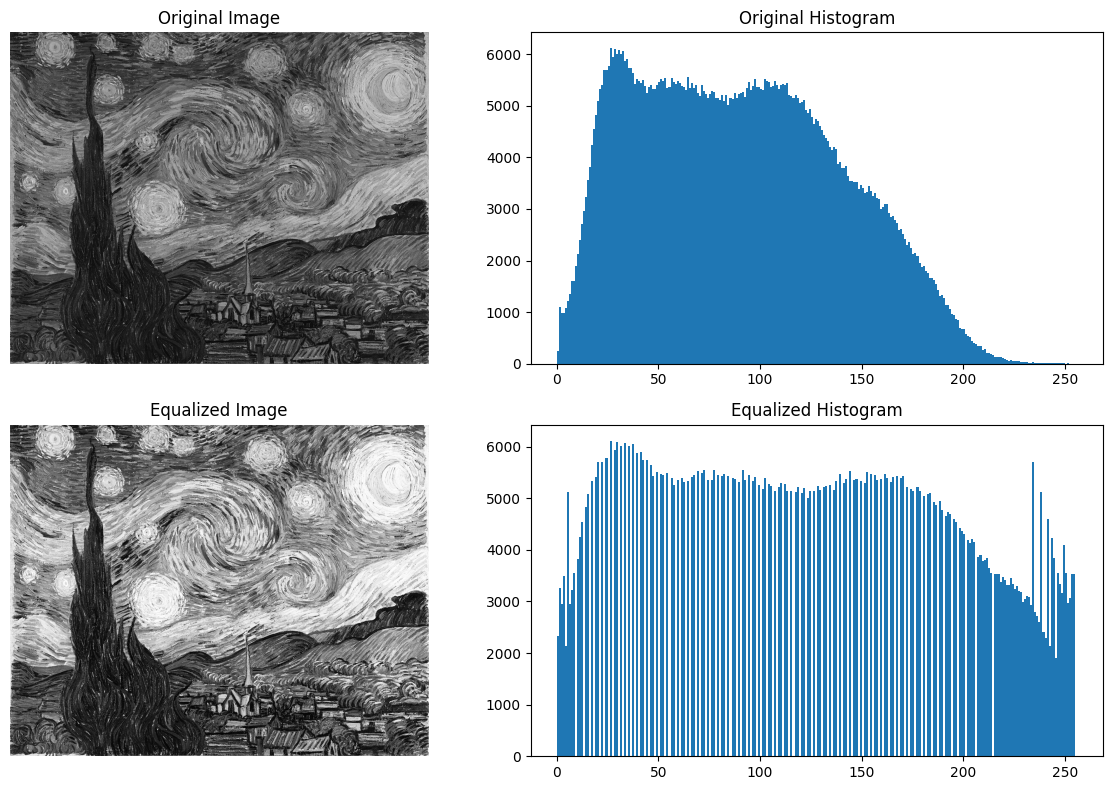

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ============================================
# Upload gambar
# ============================================

uploaded = files.upload()

# Ambil nama file
image_name = list(uploaded.keys())[0]

# Baca gambar dan ubah ke grayscale
image = Image.open(image_name).convert('L')
image = np.array(image)

# ============================================
# Manual Histogram Equalization
# ============================================

def manual_histogram_equalization(image):
    """
    Manual implementation of histogram equalization

    Parameters:
    image: grayscale image (0-255)

    Returns:
    equalized_image
    transform_function
    histogram
    """

    # 1. Hitung histogram
    histogram = np.zeros(256)

    for pixel in image.flatten():
        histogram[pixel] += 1

    # 2. Hitung cumulative histogram
    cdf = histogram.cumsum()

    # 3. Normalisasi CDF
    cdf_normalized = cdf / cdf.max()

    # 4. Fungsi transformasi
    transform = np.floor(255 * cdf_normalized).astype(np.uint8)

    # 5. Apply transformasi
    equalized_image = transform[image]

    return equalized_image, transform, histogram


# ============================================
# Jalankan Histogram Equalization
# ============================================

equalized_image, transform, histogram = manual_histogram_equalization(image)

# ============================================
# Visualisasi
# ============================================

plt.figure(figsize=(12,8))

# Original Image
plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Histogram Original
plt.subplot(2,2,2)
plt.hist(image.flatten(), bins=256, range=[0,256])
plt.title("Original Histogram")

# Equalized Image
plt.subplot(2,2,3)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

# Histogram Equalized
plt.subplot(2,2,4)
plt.hist(equalized_image.flatten(), bins=256, range=[0,256])
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

Saving xray.jpeg to xray.jpeg


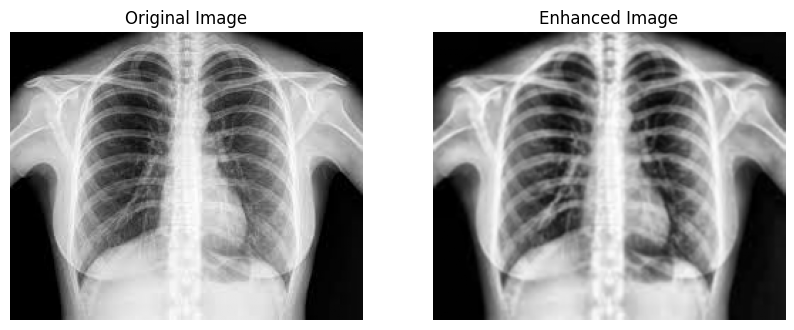

Enhancement Report:
Modality : X-ray
Contrast Before : 82.8195666070431
Contrast After : 79.27509879147972
Brightness Before : 131.4324646432544
Brightness After : 126.82389162561576
Estimated Noise Level : 119.74104856453114


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================
# Upload gambar dari komputer
# ============================================

uploaded = files.upload()

# Ambil nama file
image_name = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(image_name, cv2.IMREAD_GRAYSCALE)

# Cek apakah gambar berhasil dibaca
if image is None:
    raise ValueError("Gambar tidak berhasil dibaca. Periksa file yang diupload.")

# ============================================
# Fungsi Enhancement
# ============================================

def medical_image_enhancement(medical_image, modality='X-ray'):

    if len(medical_image.shape) == 3:
        image = cv2.cvtColor(medical_image, cv2.COLOR_BGR2GRAY)
    else:
        image = medical_image.copy()

    # Normalisasi
    image_norm = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(image_norm)

    # Enhancement berdasarkan modality
    if modality == 'X-ray':
        enhanced = cv2.GaussianBlur(clahe_img, (3,3), 0)

    elif modality == 'MRI':
        enhanced = cv2.GaussianBlur(clahe_img, (5,5), 1)

    elif modality == 'CT':
        blur = cv2.GaussianBlur(clahe_img, (3,3), 0)
        enhanced = cv2.addWeighted(clahe_img, 1.5, blur, -0.5, 0)

    elif modality == 'Ultrasound':
        enhanced = cv2.medianBlur(clahe_img, 5)

    else:
        enhanced = clahe_img

    # Metrics
    contrast_before = np.std(image_norm)
    contrast_after = np.std(enhanced)

    brightness_before = np.mean(image_norm)
    brightness_after = np.mean(enhanced)

    noise = np.std(image_norm - cv2.GaussianBlur(image_norm,(3,3),0))

    report = {
        "Modality": modality,
        "Contrast Before": float(contrast_before),
        "Contrast After": float(contrast_after),
        "Brightness Before": float(brightness_before),
        "Brightness After": float(brightness_after),
        "Estimated Noise Level": float(noise)
    }

    return enhanced, report


# ============================================
# Jalankan Enhancement
# ============================================

enhanced_image, report = medical_image_enhancement(image, modality='X-ray')


# ============================================
# Visualisasi
# ============================================

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_image, cmap='gray')
plt.title("Enhanced Image")
plt.axis("off")

plt.show()


print("Enhancement Report:")
for k,v in report.items():
    print(k,":",v)

Klik tombol CAPTURE untuk mengambil gambar dari webcam


<IPython.core.display.Javascript object>

Original Image


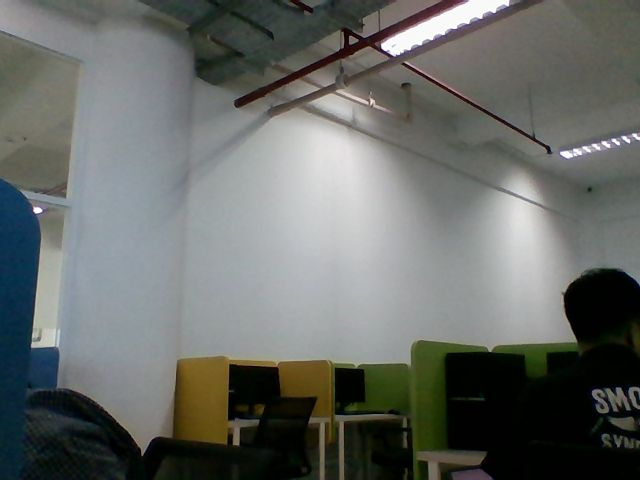

Enhanced Image


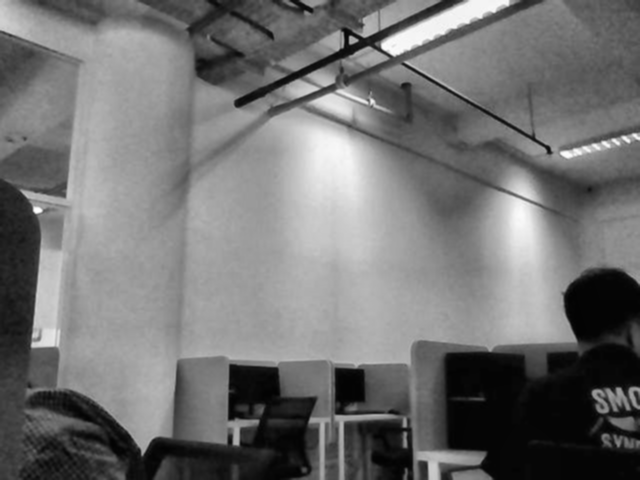

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


# ============================================
# Fungsi mengambil gambar dari webcam
# ============================================

def take_photo(filename='photo.jpg', quality=0.8):

  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = "Capture";
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))

  binary = b64decode(data.split(',')[1])

  with open(filename, 'wb') as f:
    f.write(binary)

  return filename


# ============================================
# Real-Time Enhancement Class
# ============================================

class RealTimeEnhancement:

    def __init__(self):

        self.history_buffer = []
        self.max_buffer = 5

        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def gamma_correction(self, image, gamma=1.2):

        inv_gamma = 1.0/gamma

        table = np.array([(i/255.0)**inv_gamma * 255
                          for i in np.arange(256)]).astype("uint8")

        return cv2.LUT(image, table)

    def enhance_frame(self, frame, mode='adaptive'):

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if mode == "histogram":
            enhanced = cv2.equalizeHist(gray)

        elif mode == "clahe":
            enhanced = self.clahe.apply(gray)

        elif mode == "gamma":
            enhanced = self.gamma_correction(gray)

        else:
            clahe_img = self.clahe.apply(gray)
            enhanced = cv2.GaussianBlur(clahe_img,(3,3),0)

        # temporal smoothing
        self.history_buffer.append(enhanced)

        if len(self.history_buffer) > self.max_buffer:
            self.history_buffer.pop(0)

        smoothed = np.mean(self.history_buffer,axis=0).astype(np.uint8)

        return smoothed


# ============================================
# MAIN PROGRAM
# ============================================

enhancer = RealTimeEnhancement()

print("Klik tombol CAPTURE untuk mengambil gambar dari webcam")

filename = take_photo()

image = cv2.imread(filename)

enhanced = enhancer.enhance_frame(image,'adaptive')

print("Original Image")
cv2_imshow(image)

print("Enhanced Image")
cv2_imshow(enhanced)

In [ ]:
# ============================================
# REAL-TIME VIDEO ENHANCEMENT (GOOGLE COLAB)
# ============================================

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


# ============================================
# Fungsi mengambil gambar dari webcam
# ============================================

def take_photo(filename='photo.jpg', quality=0.8):

  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = "Capture";
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);

      div.appendChild(video);
      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
        document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))

  binary = b64decode(data.split(',')[1])

  with open(filename, 'wb') as f:
    f.write(binary)

  return filename


# ============================================
# Real-Time Enhancement Class
# ============================================

class RealTimeEnhancement:

    def __init__(self):

        self.history_buffer = []
        self.max_buffer = 5

        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def gamma_correction(self, image, gamma=1.2):

        inv_gamma = 1.0/gamma

        table = np.array([(i/255.0)**inv_gamma * 255
                          for i in np.arange(256)]).astype("uint8")

        return cv2.LUT(image, table)

    def enhance_frame(self, frame, mode='adaptive'):

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if mode == "histogram":
            enhanced = cv2.equalizeHist(gray)

        elif mode == "clahe":
            enhanced = self.clahe.apply(gray)

        elif mode == "gamma":
            enhanced = self.gamma_correction(gray)

        else:
            clahe_img = self.clahe.apply(gray)
            enhanced = cv2.GaussianBlur(clahe_img,(3,3),0)

        # temporal smoothing
        self.history_buffer.append(enhanced)

        if len(self.history_buffer) > self.max_buffer:
            self.history_buffer.pop(0)

        smoothed = np.mean(self.history_buffer,axis=0).astype(np.uint8)

        return smoothed


# ============================================
# MAIN PROGRAM
# ============================================

enhancer = RealTimeEnhancement()

print("Klik tombol CAPTURE untuk mengambil gambar dari webcam")

filename = take_photo()

image = cv2.imread(filename)

# ================================
# HILANGKAN MIRROR (flip horizontal)
# ================================
image = cv2.flip(image, 1)

enhanced = enhancer.enhance_frame(image,'adaptive')

print("Original Image")
cv2_imshow(image)

print("Enhanced Image")
cv2_imshow(enhanced)

Klik tombol CAPTURE untuk mengambil gambar dari webcam


<IPython.core.display.Javascript object>

KeyboardInterrupt: 